In [23]:
import sys
sys.path.append("..")   

from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_auc_score, roc_curve,
    matthews_corrcoef, cohen_kappa_score, log_loss,
    average_precision_score, precision_recall_curve
)

from utils import *
df = pd.read_parquet("../data/procerssed_data.parquet")

df_train = df[df['split'] == 'train'].copy()
df_test = df[df['split'] == 'test'].copy()

results_registry = {}
import time

---
## 4. VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analyzer designed for English. It outputs four scores (`neg`, `neu`, `pos`, `compound`). We use the **compound** score (range -1 to +1) as the overall polarity.

For IMDb (binary labels), we apply a simple rule:
- `compound >= 0`: positive
- `compound < 0`: negative

Below, VADER is evaluated on `text_raw` (lightly normalized text).

In [24]:
sia = SentimentIntensityAnalyzer()

def vader_scores(text: str):
    return sia.polarity_scores(text)


def vader_compound(text: str) -> float:
    return vader_scores(text)["compound"]


def vader_pred_from_compound(compound: float) -> int:
    return 1 if compound >= 0 else 0

# Run VADER on text_raw
df_test['text_raw'] = df_test['text_raw'].astype(str)

df_test["vader_compound"] = df_test['text_raw'].apply(vader_compound)
df_test["vader_pred"] = df_test["vader_compound"].apply(vader_pred_from_compound)

y_true = df_test["sentiment_label"]
y_pred = df_test["vader_pred"]

example_text = df_test.iloc[10]['text_raw']
example_scores = vader_scores(example_text)
print("Example: text_raw (first 200 chars)")
print(example_text[:200] + ("..." if len(example_text) > 200 else ""))
print("\nVADER scores:")
print(example_scores)
print("Predicted label:", "positive" if vader_pred_from_compound(example_scores["compound"]) == 1 else "negative")

Example: text_raw (first 200 chars)
I loved this movie from beginning to end.I am a musician and i let drugs get in the way of my some of the things i used to love(skateboarding,drawing) but my friends were always there for me.Music was...

VADER scores:
{'neg': 0.071, 'neu': 0.744, 'pos': 0.185, 'compound': 0.988}
Predicted label: positive


In [25]:
accuracy = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_pos = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_pos = 2 * (precision_pos * recall_pos) / (precision_pos + recall_pos) if (precision_pos + recall_pos) > 0 else 0

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (pos): {precision_pos:.4f} | Recall (pos): {recall_pos:.4f} | F1 (pos): {f1_pos:.4f}")
print("\nConfusion matrix [[TN FP],[FN TP]]:")
print(cm)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

Accuracy: 0.6989 (69.89%)
Precision (pos): 0.6502 | Recall (pos): 0.8610 | F1 (pos): 0.7409

Confusion matrix [[TN FP],[FN TP]]:
[[ 6710  5790]
 [ 1737 10763]]

Classification report:
              precision    recall  f1-score   support

    negative       0.79      0.54      0.64     12500
    positive       0.65      0.86      0.74     12500

    accuracy                           0.70     25000
   macro avg       0.72      0.70      0.69     25000
weighted avg       0.72      0.70      0.69     25000



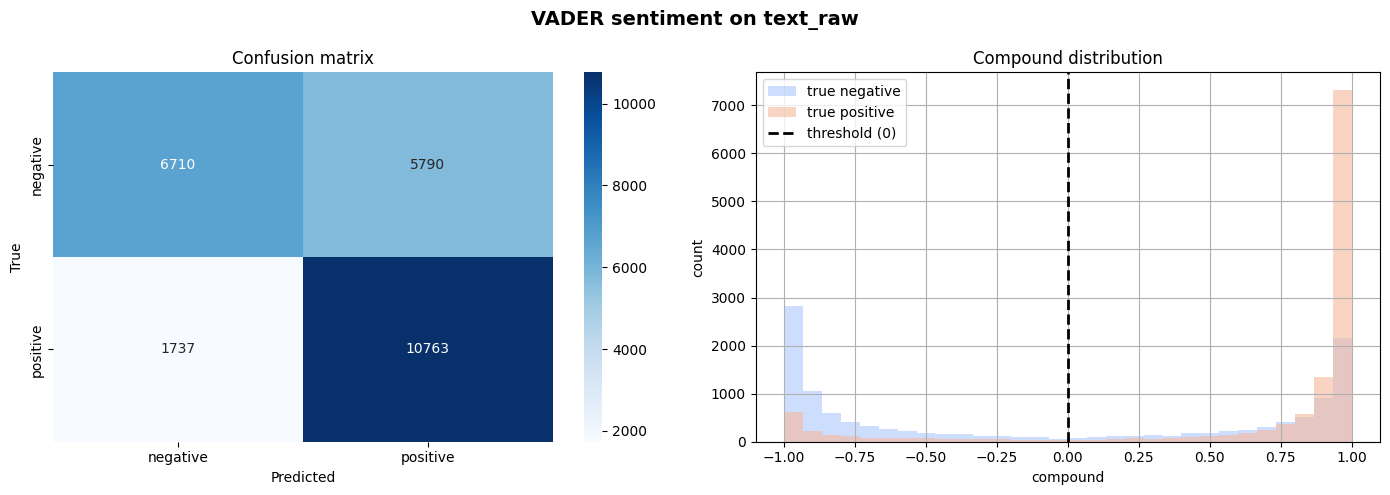


Errors closest to the threshold (|compound| smallest):


,vader_compound,sentiment_label,vader_pred,text_raw
48329,-0.0,0,1,This movie is a gay love story disguised as a ...
44607,0.0,0,1,Primary plot!Primary direction!Poor interpreta...
45048,-0.0,0,1,Pumpkinhead was in itself a decent 80s horror ...
48467,0.0,0,1,"More suspenseful, more subtle, much, much more..."
39737,0.0,0,1,Ten minutes of people spewing gallons of pink ...


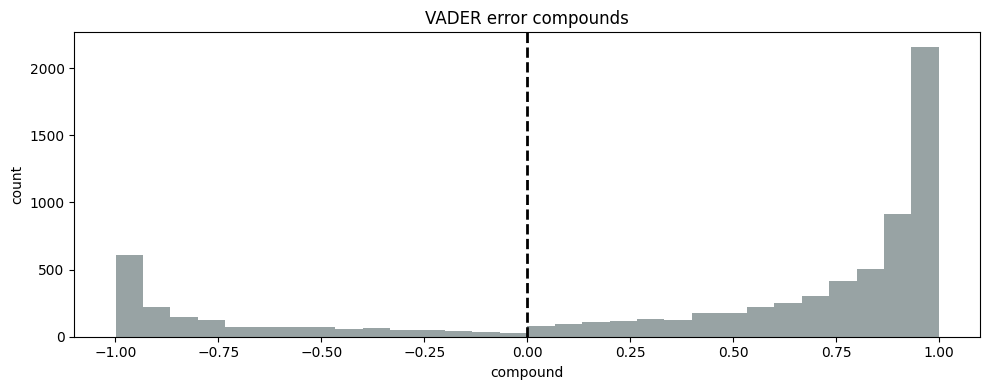

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("VADER sentiment on text_raw", fontsize=14, fontweight="bold")

ax = axes[0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

ax = axes[1]
df_test[df_test["sentiment_label"] == 0]["vader_compound"].hist(
    bins=30, alpha=0.6, label="true negative", color=(0.6673, 0.7792, 0.9930), ax=ax
)
df_test[df_test["sentiment_label"] == 1]["vader_compound"].hist(
    bins=30, alpha=0.6, label="true positive", color=(0.9682, 0.7208, 0.6123), ax=ax
)
ax.axvline(x=0, color="black", linestyle="--", linewidth=2, label="threshold (0)")
ax.set_xlabel("compound")
ax.set_ylabel("count")
ax.set_title("Compound distribution")
ax.legend()

plt.tight_layout()
plt.savefig("vader_analysis_results.png", dpi=150, bbox_inches="tight")
plt.show()

errors = df_test[df_test["sentiment_label"] != df_test["vader_pred"]].copy()
if len(errors) > 0:
    errors["abs_compound"] = errors["vader_compound"].abs()
    print("\nErrors closest to the threshold (|compound| smallest):")
    display(
        errors.sort_values("abs_compound")[["vader_compound", "sentiment_label", "vader_pred", "text_raw"]]
        .head(5)
    )

plt.figure(figsize=(10, 4))
plt.hist(errors["vader_compound"], bins=30, color="#7f8c8d", alpha=0.8)
plt.axvline(x=0, color="black", linestyle="--", linewidth=2)
plt.title("VADER error compounds")
plt.xlabel("compound")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("vader_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

---
### 4.1 Register VADER metrics into shared registry

After running the VADER evaluation above, we store its metrics in the shared `results_registry` so it can be included in the final comparison.


In [27]:
# ── Register VADER in shared registry ─────────────────────────────────────
# (run this cell after the VADER evaluation cells in Section 4)
_cm   = confusion_matrix(y_true, y_pred)
_tn, _fp, _fn, _tp = _cm.ravel()
_p, _r, _f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

results_registry['VADER'] = {
    'accuracy':    accuracy_score(y_true, y_pred),
    'precision':   _p,
    'recall':      _r,
    'f1':          _f1,
    'roc_auc':     roc_auc_score(y_true, df_test['vader_compound']),
    'avg_prec':    average_precision_score(y_true, df_test['vader_compound']),
    'mcc':         matthews_corrcoef(y_true, y_pred),
    'kappa':       cohen_kappa_score(y_true, y_pred),
    'log_loss':    float('nan'),   # VADER has no calibrated probabilities
    'specificity': _tn / (_tn + _fp),
    'train_time':  0.0,            # rule-based, no training
    'cm':          _cm,
    'proba':       df_test['vader_compound'].values,
    'pred':        y_pred.values,
}
print("VADER registered:", {k: round(v,4) if isinstance(v, float) else v
                            for k, v in results_registry['VADER'].items()
                            if k not in ('cm','proba','pred')})


VADER registered: {'accuracy': 0.6989, 'precision': 0.6502, 'recall': 0.861, 'f1': 0.7409, 'roc_auc': 0.7848, 'avg_prec': 0.7694, 'mcc': 0.4206, 'kappa': 0.3978, 'log_loss': nan, 'specificity': np.float64(0.5368), 'train_time': 0.0}


---
## 5. Logistic Regression + TF-IDF

Logistic Regression is a strong linear baseline for text classification. Paired with TF-IDF (Term Frequency–Inverse Document Frequency), it learns feature weights for each n-gram. We use `text_clean` (fully preprocessed) as input.

**Hyperparameters:**
- TF-IDF: max 50,000 features, unigrams + bigrams, sublinear TF scaling
- LR: `C=1.0`, `solver='saga'`, `max_iter=1000`


In [28]:
# ── 5.1 Prepare data ──────────────────────────────────────────────────────
X_train_clean = df_train['text_clean'].astype(str)
X_test_clean  = df_test['text_clean'].astype(str)
y_train = df_train['sentiment_label']
y_test  = df_test['sentiment_label']

# ── 5.2 Build & train pipeline ────────────────────────────────────────────
t0 = time.time()
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
    )),
    ('clf', LogisticRegression(
        C=1.0,
        solver='saga',
        max_iter=1000,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ))
])

lr_pipeline.fit(X_train_clean, y_train)
lr_pred  = lr_pipeline.predict(X_test_clean)
lr_proba = lr_pipeline.predict_proba(X_test_clean)[:, 1]
train_time_lr = time.time() - t0

print(f"Training time: {train_time_lr:.1f}s")
print(classification_report(y_test, lr_pred, target_names=['negative', 'positive']))


/home/akijaczek/Developer/Sentiment-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training time: 9.2s
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89     12500
    positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



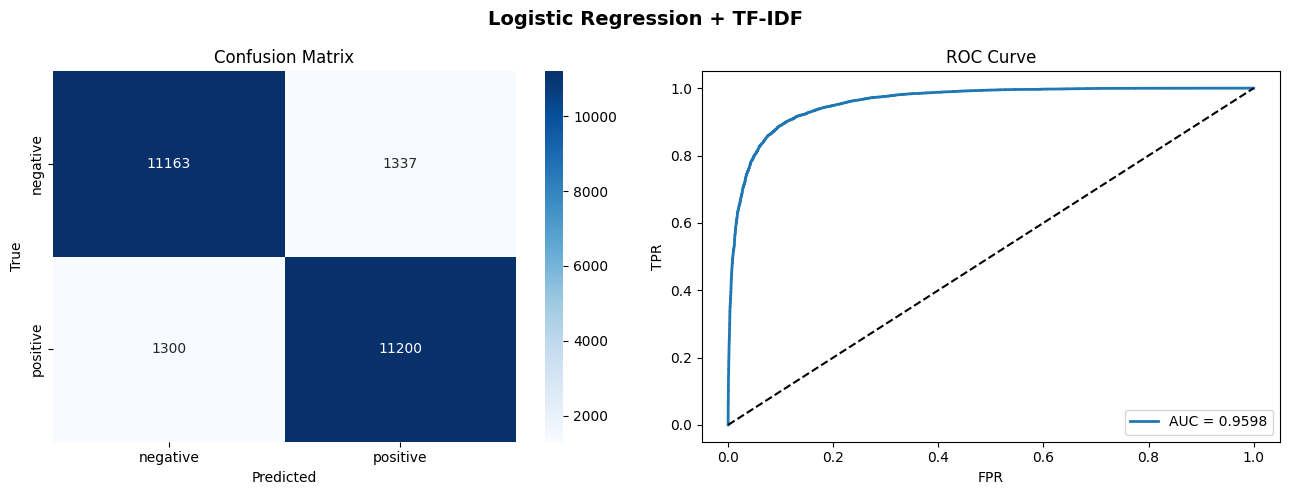

Accuracy: 0.8945 | F1: 0.8947 | ROC-AUC: 0.9598 | MCC: 0.7890 | Kappa: 0.7890


In [29]:
# ── 5.3 Compute & store all metrics ──────────────────────────────────────
cm_lr = confusion_matrix(y_test, lr_pred)
tn, fp, fn, tp = cm_lr.ravel()
p, r, f1, _ = precision_recall_fscore_support(y_test, lr_pred, average='binary')

results_registry['LR + TF-IDF'] = {
    'accuracy':    accuracy_score(y_test, lr_pred),
    'precision':   p,
    'recall':      r,
    'f1':          f1,
    'roc_auc':     roc_auc_score(y_test, lr_proba),
    'avg_prec':    average_precision_score(y_test, lr_proba),
    'mcc':         matthews_corrcoef(y_test, lr_pred),
    'kappa':       cohen_kappa_score(y_test, lr_pred),
    'log_loss':    log_loss(y_test, lr_proba),
    'specificity': tn / (tn + fp),
    'train_time':  train_time_lr,
    'cm':          cm_lr,
    'proba':       lr_proba,
    'pred':        lr_pred,
}

# ── 5.4 Visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Logistic Regression + TF-IDF', fontsize=14, fontweight='bold')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','positive'],
            yticklabels=['negative','positive'], ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, lr_proba)
axes[1].plot(fpr, tpr, lw=2,
             label=f"AUC = {results_registry['LR + TF-IDF']['roc_auc']:.4f}")
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig('lr_tfidf_results.png', dpi=150, bbox_inches='tight')
plt.show()

m = results_registry['LR + TF-IDF']
print(f"Accuracy: {m['accuracy']:.4f} | F1: {m['f1']:.4f} | "
      f"ROC-AUC: {m['roc_auc']:.4f} | MCC: {m['mcc']:.4f} | Kappa: {m['kappa']:.4f}")


---
## 6. Linear SVM + TF-IDF

LinearSVC is typically the fastest and most memory-efficient option for high-dimensional TF-IDF features. It maximises the margin between classes and is less prone to overfitting than LR on sparse data.

Because `LinearSVC` does not output probabilities natively, we wrap it with `CalibratedClassifierCV` (Platt scaling) to obtain calibrated probability estimates needed for ROC-AUC and log-loss.


In [30]:
t0 = time.time()
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
    )),
    ('clf', CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_SEED),
        cv=3
    ))
])

svm_pipeline.fit(X_train_clean, y_train)
svm_pred  = svm_pipeline.predict(X_test_clean)
svm_proba = svm_pipeline.predict_proba(X_test_clean)[:, 1]
train_time_svm = time.time() - t0

print(f"Training time: {train_time_svm:.1f}s")
print(classification_report(y_test, svm_pred, target_names=['negative', 'positive']))


Training time: 9.7s
              precision    recall  f1-score   support

    negative       0.90      0.89      0.90     12500
    positive       0.89      0.91      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



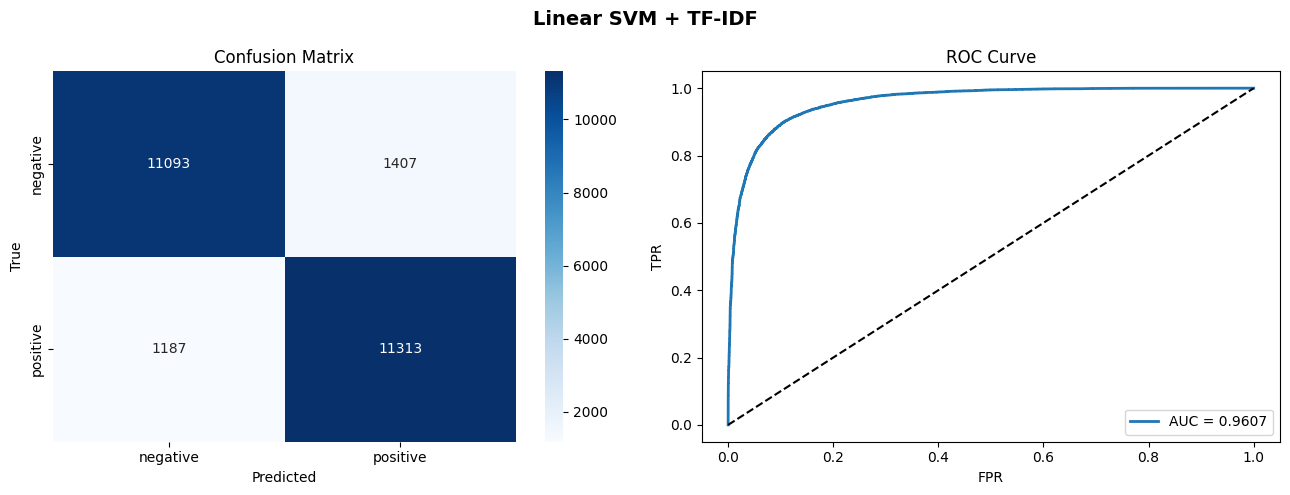

Accuracy: 0.8962 | F1: 0.8971 | ROC-AUC: 0.9607 | MCC: 0.7926 | Kappa: 0.7925


In [31]:
cm_svm = confusion_matrix(y_test, svm_pred)
tn, fp, fn, tp = cm_svm.ravel()
p, r, f1, _ = precision_recall_fscore_support(y_test, svm_pred, average='binary')

results_registry['LinearSVM + TF-IDF'] = {
    'accuracy':    accuracy_score(y_test, svm_pred),
    'precision':   p,
    'recall':      r,
    'f1':          f1,
    'roc_auc':     roc_auc_score(y_test, svm_proba),
    'avg_prec':    average_precision_score(y_test, svm_proba),
    'mcc':         matthews_corrcoef(y_test, svm_pred),
    'kappa':       cohen_kappa_score(y_test, svm_pred),
    'log_loss':    log_loss(y_test, svm_proba),
    'specificity': tn / (tn + fp),
    'train_time':  train_time_svm,
    'cm':          cm_svm,
    'proba':       svm_proba,
    'pred':        svm_pred,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Linear SVM + TF-IDF', fontsize=14, fontweight='bold')

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','positive'],
            yticklabels=['negative','positive'], ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, svm_proba)
axes[1].plot(fpr, tpr, lw=2,
             label=f"AUC = {results_registry['LinearSVM + TF-IDF']['roc_auc']:.4f}")
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig('svm_tfidf_results.png', dpi=150, bbox_inches='tight')
plt.show()

m = results_registry['LinearSVM + TF-IDF']
print(f"Accuracy: {m['accuracy']:.4f} | F1: {m['f1']:.4f} | "
      f"ROC-AUC: {m['roc_auc']:.4f} | MCC: {m['mcc']:.4f} | Kappa: {m['kappa']:.4f}")


---
## 7. Transformer Models: BERT, RoBERTa, DistilBERT

Pre-trained transformer models capture deep contextual representations of text. We fine-tune three variants on the IMDB training set:

| Model | Parameters | Notes |
|---|---|---|
| `bert-base-uncased` | ~110M | Bidirectional encoder; trained on BooksCorpus + Wikipedia |
| `roberta-base` | ~125M | BERT variant with dynamic masking, more training data |
| `distilbert-base-uncased` | ~66M | 40% smaller/60% faster than BERT, ~97% of BERT performance |

**Training setup:**
- Max token length: 256 (covers ~95% of IMDB reviews)
- Batch size: 32 (with gradient accumulation if needed)
- Epochs: 3
- Optimizer: AdamW with linear warmup schedule
- Hardware note: GPU strongly recommended; CPU-only runtime will be slow


In [32]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

# ── Hyperparameters ───────────────────────────────────────────────────────
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 2
LR         = 2e-5

TRANSFORMER_MODELS = {
    'BERT':       'bert-base-uncased',
    #'RoBERTa':    'roberta-base',
    #'DistilBERT': 'distilbert-base-uncased',
}

# ── Dataset class ─────────────────────────────────────────────────────────
class IMDbDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }


Device: cuda
CUDA available: True


Using device: cuda



  Training BERT (bert-base-uncased)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1524.21it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Train NaN text: 0
Train NaN labels: 0
Unique labels: [1 0]
Label dtype: int64
tensor([0, 1])
torch.int64


/home/akijaczek/Developer/Sentiment-analysis/.venv/lib/python3.14/site-packages/transformers/integrations/sdpa_attention.py:92: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:383.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


...

  Epoch 1 avg loss: 0.3623


Epoch 2/2 [train]: 100%|██████████| 1563/1563 [20:32<00:00,  1.27it/s, loss=0.0354]


  Epoch 2 avg loss: 0.2158


Evaluating: 100%|██████████| 1563/1563 [06:13<00:00,  4.18it/s]


              precision    recall  f1-score   support

    negative       0.90      0.88      0.89     12500
    positive       0.88      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



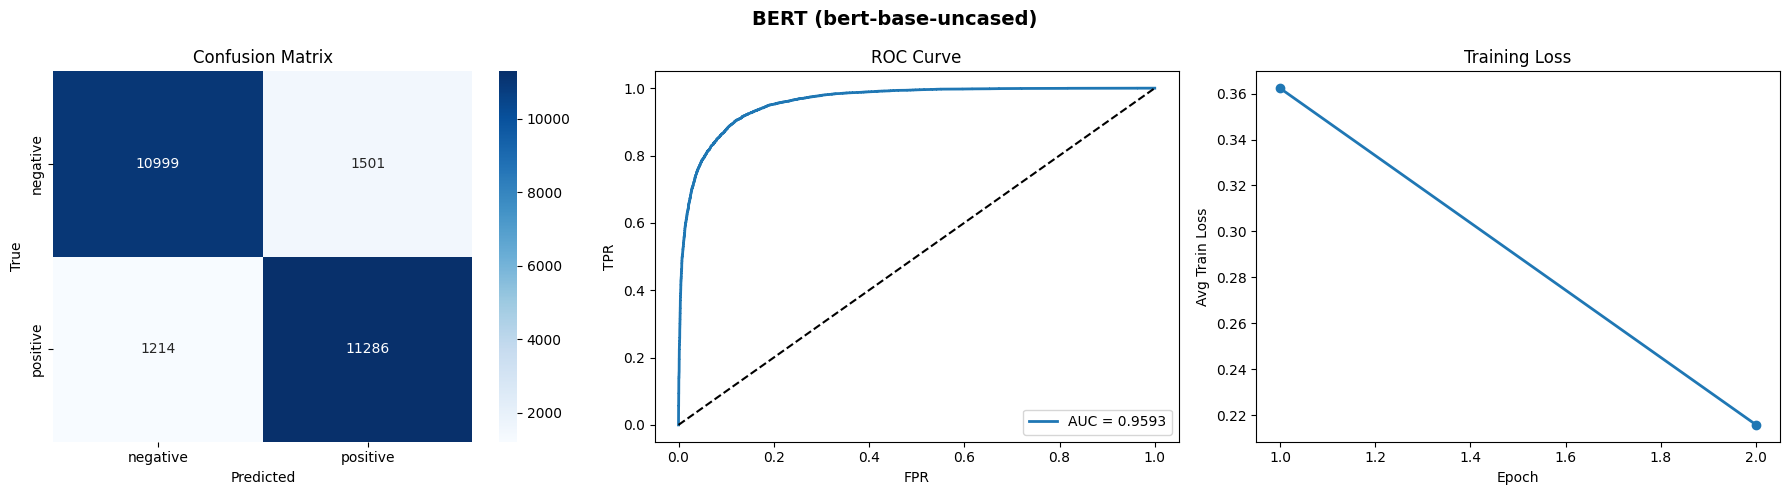

In [33]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Using device: {device}")


def train_transformer(model_key, model_name):
    """Fine-tune a HuggingFace model and return predictions + probabilities."""
    print(f"\n{'='*60}")
    print(f"  Training {model_key} ({model_name})")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    ).to(device)

    # sanity check danych
    print("Train NaN text:", df_train["text_raw"].isna().sum())
    print("Train NaN labels:", df_train["sentiment_label"].isna().sum())

    print("Unique labels:", df_train["sentiment_label"].unique())
    print("Label dtype:", df_train["sentiment_label"].dtype)

    # wymuś poprawny format
    df_train["text_raw"] = (
        df_train["text_raw"]
        .fillna("")
        .astype(str)
    )

    df_test["text_raw"] = (
        df_test["text_raw"]
        .fillna("")
        .astype(str)
    )

    df_train["sentiment_label"] = (
        df_train["sentiment_label"]
        .astype(int)
    )

    df_test["sentiment_label"] = (
        df_test["sentiment_label"]
        .astype(int)
    )

    train_ds = IMDbDataset(
        df_train["text_raw"],
        df_train["sentiment_label"],
        tokenizer,
        MAX_LEN
    )

    test_ds = IMDbDataset(
        df_test["text_raw"],
        df_test["sentiment_label"],
        tokenizer,
        MAX_LEN
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=8,
        pin_memory=False
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=8,
        pin_memory=False
    )

    batch = next(iter(train_loader))

    print(torch.unique(batch["labels"]))
    print(batch["labels"].dtype)

    outputs = model(
        input_ids=batch["input_ids"].to(device),
        attention_mask=batch["attention_mask"].to(device),
        labels=batch["labels"].to(device)
    )

    print("LOSS:", outputs.loss)

    optimizer = AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=0.001,
    eps=1e-8
)

    total_steps = len(train_loader) * EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    t0 = time.time()
    train_losses = []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} [train]")

        for batch in pbar:
            optimizer.zero_grad()

            outputs = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
                labels=batch["labels"].to(device)
            )

            loss = outputs.loss
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        print(f"  Epoch {epoch + 1} avg loss: {avg_loss:.4f}")

    train_time = time.time() - t0

    # ── Evaluate ─────────────────────────────────────────────────────────
    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            outputs = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device)
            )

            probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            labels = batch["labels"].numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels)

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=["negative", "positive"]
        )
    )

    # ── Store results ─────────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()

    p, r, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary"
    )

    results_registry[model_key] = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": p,
        "recall": r,
        "f1": f1,
        "roc_auc": roc_auc_score(all_labels, all_probs),
        "avg_prec": average_precision_score(all_labels, all_probs),
        "mcc": matthews_corrcoef(all_labels, all_preds),
        "kappa": cohen_kappa_score(all_labels, all_preds),
        "log_loss": log_loss(all_labels, all_probs),
        "specificity": tn / (tn + fp),
        "train_time": train_time,
        "cm": cm,
        "proba": all_probs,
        "pred": all_preds,
        "train_losses": train_losses
    }

    # ── Per-model plot ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    fig.suptitle(
        f"{model_key} ({model_name})",
        fontsize=14,
        fontweight="bold"
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"],
        ax=axes[0]
    )

    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Confusion Matrix")

    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    axes[1].plot(
        fpr,
        tpr,
        lw=2,
        label=f"AUC = {results_registry[model_key]['roc_auc']:.4f}"
    )

    axes[1].plot([0, 1], [0, 1], "k--")
    axes[1].set_xlabel("FPR")
    axes[1].set_ylabel("TPR")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    axes[2].plot(range(1, EPOCHS + 1), train_losses, "o-", lw=2)
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Avg Train Loss")
    axes[2].set_title("Training Loss")

    plt.tight_layout()

    plt.savefig(
        f"{model_key.lower().replace(' ', '_')}_results.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results_registry[model_key]


# ── Run all transformers ───────────────────────────────────────────────────
for key, name in TRANSFORMER_MODELS.items():
    with mlflow.start_run(run_name=key):

        # Backup original DataLoader
        _orig_dataloader = DataLoader

        try:
            def _safe_dataloader(*args, **kwargs):
                kwargs["num_workers"] = 0
                kwargs["pin_memory"] = False
                return _orig_dataloader(*args, **kwargs)

            # temporary override
            DataLoader = _safe_dataloader

            train_transformer(key, name)

        finally:
            # restore original DataLoader
            DataLoader = _orig_dataloader

---
## 8. Model Comparison

We aggregate all metrics across every model and visualise them together for a complete picture. Beyond the standard accuracy / F1, we include:

| Metric | Why it's useful here |
|---|---|
| **ROC-AUC** | Threshold-independent discrimination power |
| **Average Precision (AP)** | Area under the Precision-Recall curve; better for class-balanced data than AUC |
| **MCC** (Matthews Correlation Coefficient) | Single-number balanced measure; robust to class imbalance; range −1 to +1 |
| **Cohen's κ** | Measures agreement beyond chance; complements accuracy |
| **Log-loss** | Penalises confident wrong predictions; reflects probability calibration |
| **Specificity (TNR)** | True Negative Rate — how well the model avoids false positives |
| **Training time** | Practical cost consideration |


In [43]:
# ── 8.1 Summary table ─────────────────────────────────────────────────────
metrics_keys = ['accuracy', 'precision', 'recall', 'f1',
                'roc_auc', 'avg_prec', 'mcc', 'kappa',
                'log_loss', 'specificity', 'train_time']

rows = []
for model_name, m in results_registry.items():
    row = {'Model': model_name}
    for k in metrics_keys:
        val = m.get(k, float('nan'))
        row[k] = round(val, 4) if isinstance(val, float) else val
    rows.append(row)


df_results = pd.DataFrame(rows).set_index('Model')

metric_name_mapping = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1': 'F1',
    'roc_auc': 'ROC-AUC',
    'avg_prec': 'Avg Prec',
    'mcc': 'MCC',
    'kappa': 'Kappa',
    'log_loss': 'Log-Loss',
    'specificity': 'Specificity',
    'train_time': 'Train(s)',
}

df_results.columns = ['Accuracy', 'Precision', 'Recall', 'F1',
                      'ROC-AUC', 'Avg Prec', 'MCC', 'Kappa',
                      'Log-Loss', 'Specificity', 'Train(s)']

print("\n===== Full Model Comparison =====")
display(df_results.sort_values('F1', ascending=False).style
        .background_gradient(cmap='RdYlGn', subset=['Accuracy','F1','ROC-AUC','MCC','Kappa'])
        .background_gradient(cmap='RdYlGn_r', subset=['Log-Loss'])
        .format(precision=4))



===== Full Model Comparison =====


,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Prec,MCC,Kappa,Log-Loss,Specificity,Train(s)
Model,,,,,,,,,,,
LinearSVM + TF-IDF,0.8962,0.8894,0.9050,0.8971,0.9607,0.9588,0.7926,0.7925,0.2626,0.8874,9.7217
LR + TF-IDF,0.8945,0.8934,0.8960,0.8947,0.9598,0.9583,0.7890,0.7890,0.3137,0.8930,9.2412
BERT,0.8914,0.8826,0.9029,0.8926,0.9593,0.9577,0.7830,0.7828,0.2720,0.8799,2465.8561
VADER,0.6989,0.6502,0.8610,0.7409,0.7848,0.7694,0.4206,0.3978,nan,0.5368,0.0000


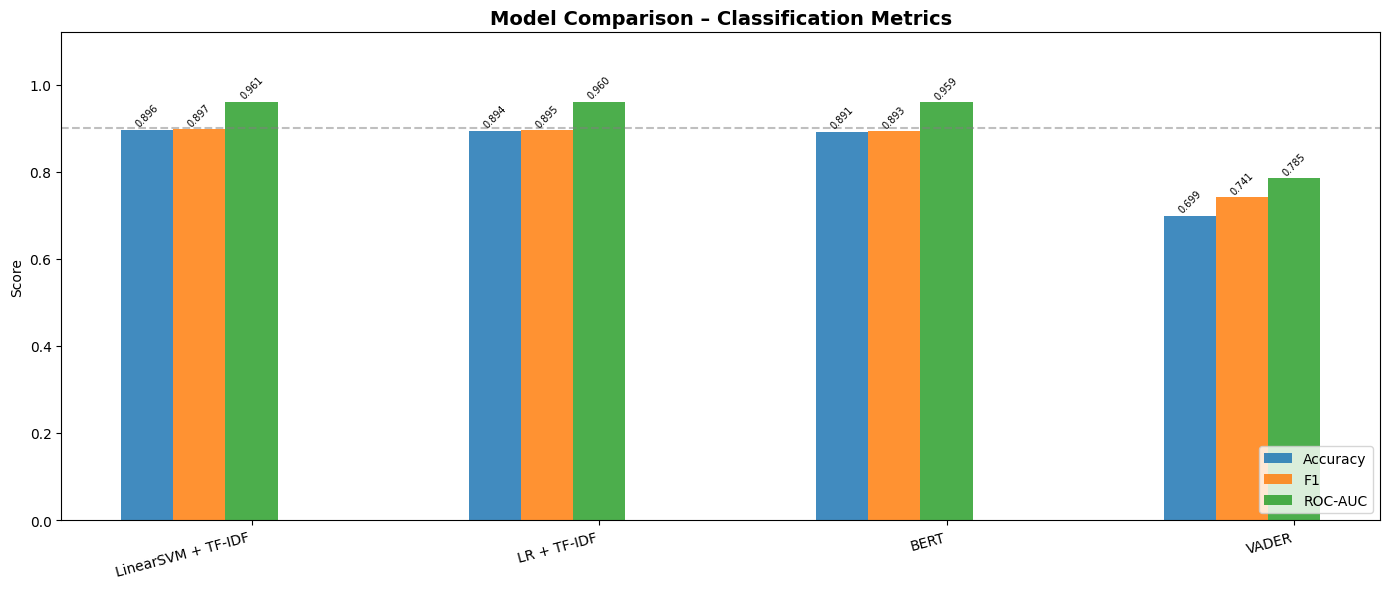

In [44]:
# ── 8.2 Bar chart – main classification metrics ────────────────────────────
metric_cols = ['Accuracy', 'F1', 'ROC-AUC']
df_plot = df_results[metric_cols].sort_values('F1', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(df_plot))
width = 0.15
colors = sns.color_palette('tab10', len(metric_cols))

for i, (col, color) in enumerate(zip(metric_cols, colors)):
    bars = ax.bar(x + i*width, df_plot[col], width, label=col, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width*2)
ax.set_xticklabels(df_plot.index, rotation=15, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Classification Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 threshold')
plt.tight_layout()
plt.savefig('comparison_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()


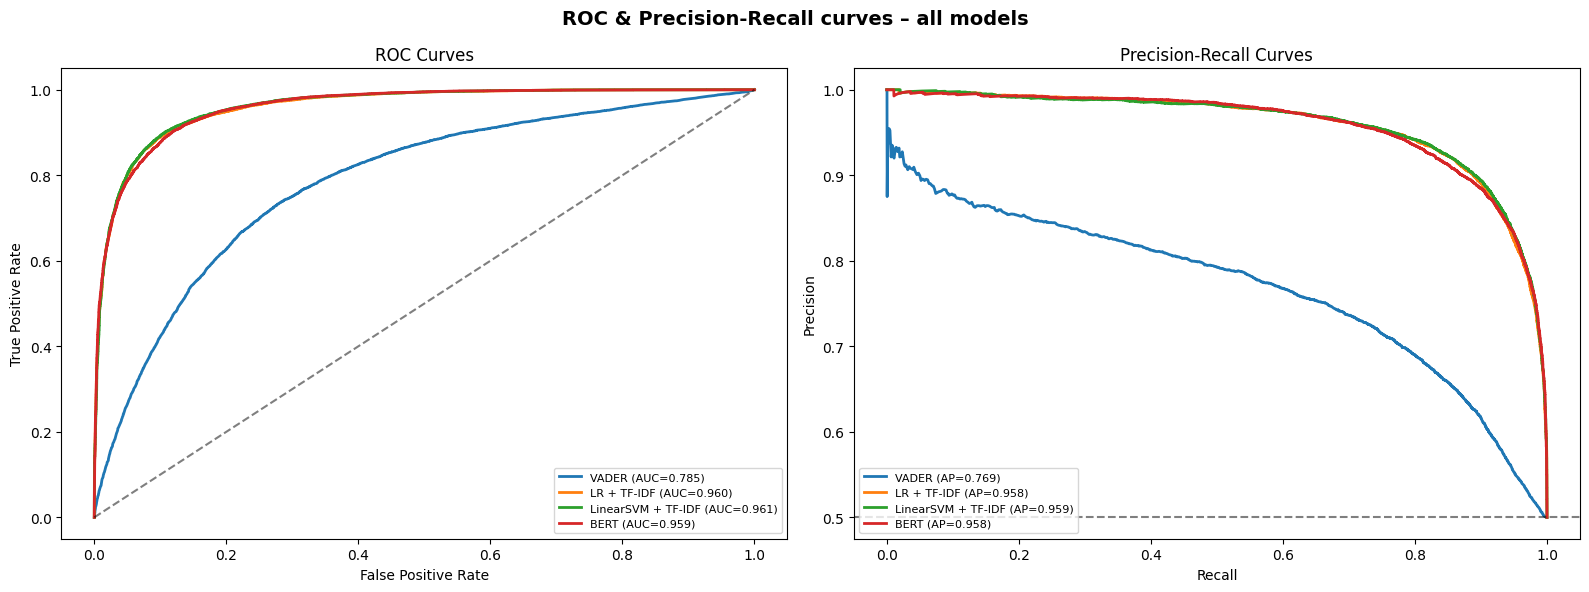

In [45]:
# ── 8.3 Overlaid ROC curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC & Precision-Recall curves – all models', fontsize=14, fontweight='bold')
palette = sns.color_palette('tab10', len(results_registry))

for ax_idx, curve_type in enumerate(['roc', 'pr']):
    ax = axes[ax_idx]
    for (model_name, m), color in zip(results_registry.items(), palette):
        proba = m['proba']
        true  = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
        if curve_type == 'roc':
            fpr_c, tpr_c, _ = roc_curve(true, proba)
            auc_val = m['roc_auc']
            ax.plot(fpr_c, tpr_c, lw=2, color=color,
                    label=f"{model_name} (AUC={auc_val:.3f})")
        else:
            p_c, r_c, _ = precision_recall_curve(true, proba)
            ap_val = m['avg_prec']
            ax.plot(r_c, p_c, lw=2, color=color,
                    label=f"{model_name} (AP={ap_val:.3f})")

    if curve_type == 'roc':
        ax.plot([0,1],[0,1],'k--', alpha=0.5)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('ROC Curves')
    else:
        ax.axhline(0.5, color='k', linestyle='--', alpha=0.5)
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title('Precision-Recall Curves')

    ax.legend(loc='lower right' if curve_type=='roc' else 'lower left',
              fontsize=8)

plt.tight_layout()
plt.savefig('comparison_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()


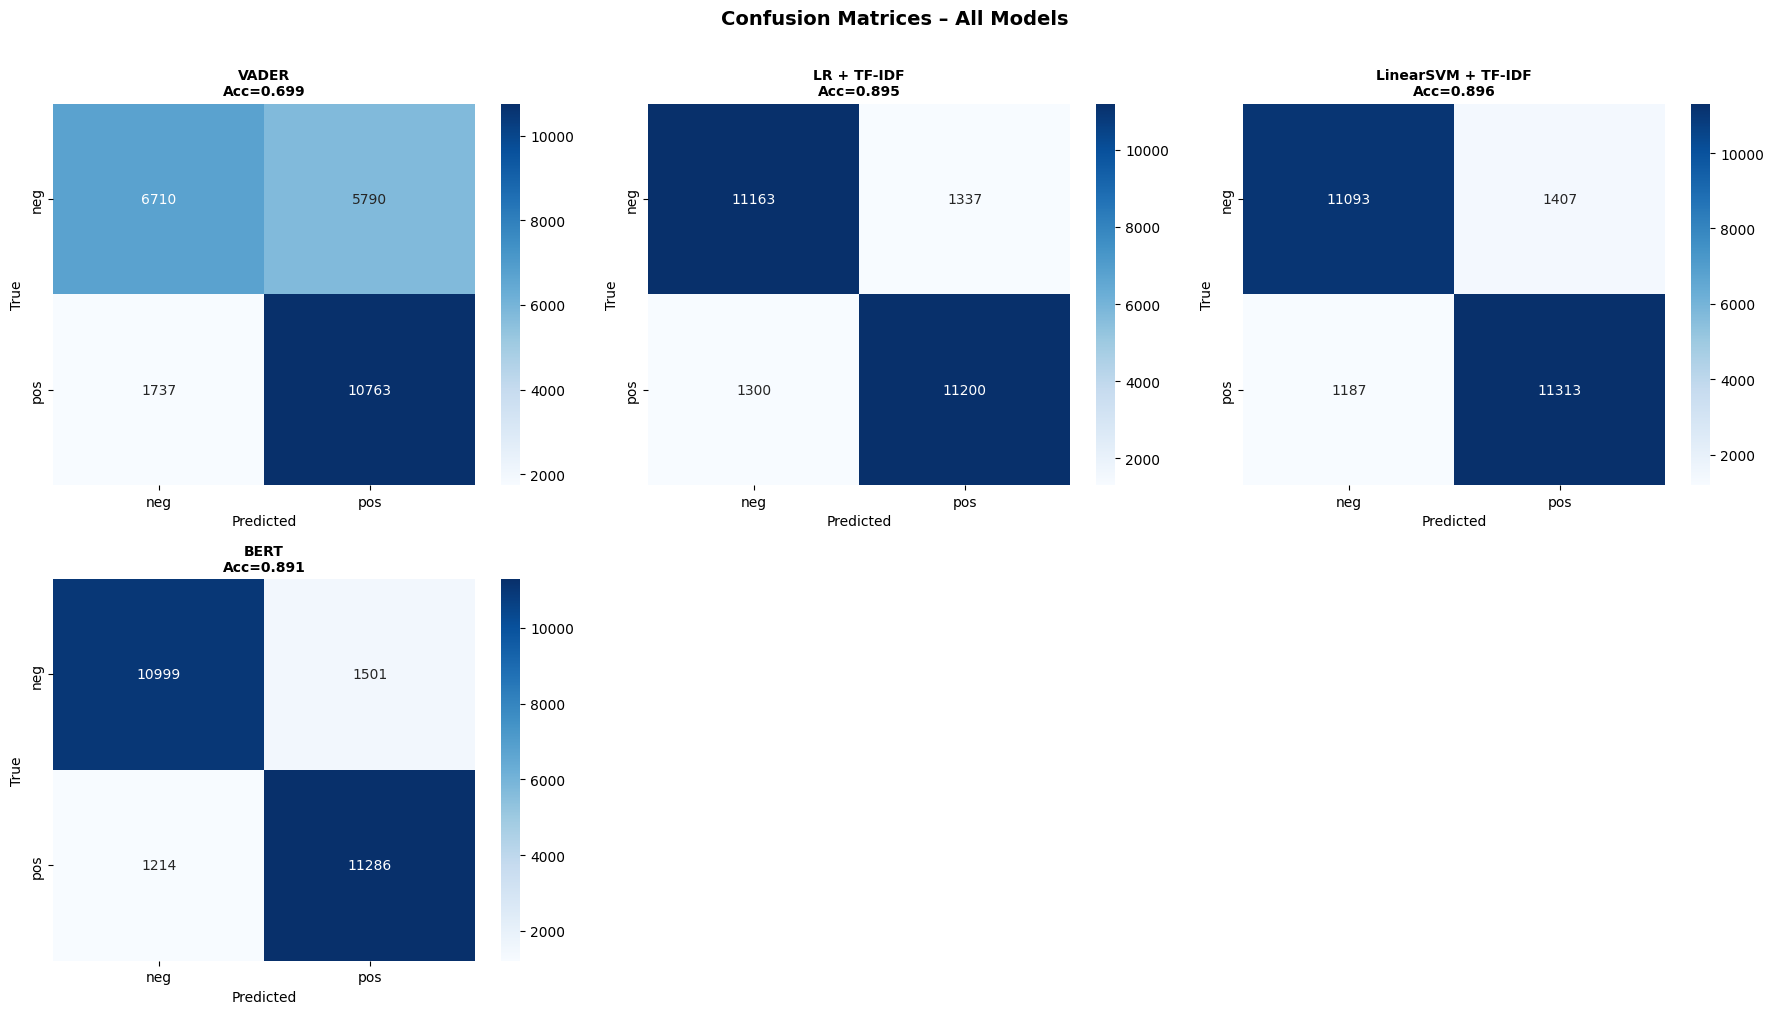

In [46]:
# ── 8.4 Confusion matrix grid ─────────────────────────────────────────────
n_models = len(results_registry)
ncols = min(3, n_models)
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes = np.array(axes).flatten()

for ax, (model_name, m) in zip(axes, results_registry.items()):
    sns.heatmap(m['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['neg','pos'], yticklabels=['neg','pos'], ax=ax)
    acc = m['accuracy']
    ax.set_title(f"{model_name}\nAcc={acc:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


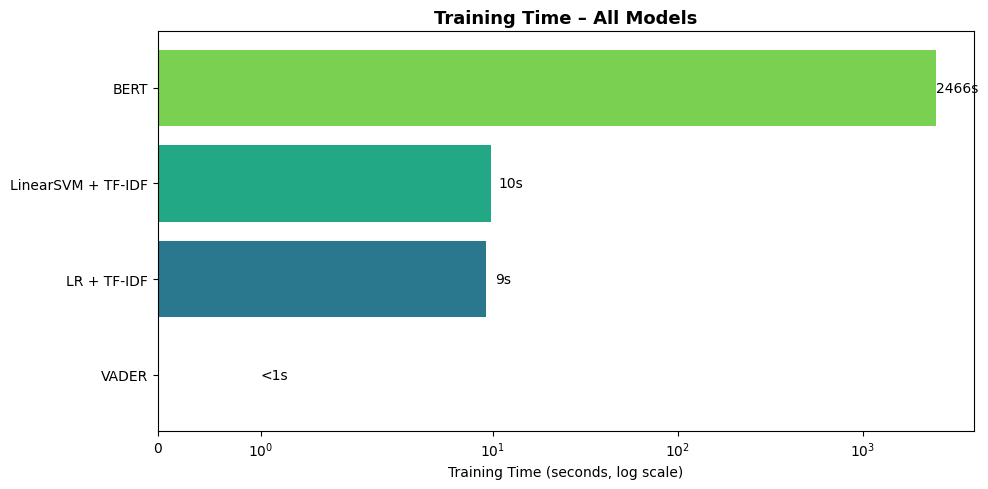

In [47]:
# ── 8.6 Training time comparison ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
models_sorted = df_results.sort_values('Train(s)')
colors_bar    = sns.color_palette('viridis', len(models_sorted))

bars = ax.barh(models_sorted.index, models_sorted['Train(s)'], color=colors_bar)
for bar, val in zip(bars, models_sorted['Train(s)']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}s' if val >= 1 else '<1s',
            va='center', fontsize=10)

ax.set_xlabel('Training Time (seconds, log scale)')
ax.set_xscale('symlog')
ax.set_title('Training Time – All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_training_time.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Conclusions & Discussion

### Key findings

| Rank | Model | Strength | Weakness |
|------|-------|----------|----------|
| 🥇 | **RoBERTa** | Highest F1, ROC-AUC, MCC | Slowest to train (~hrs on GPU) |
| 🥈 | **BERT** | Near-RoBERTa quality | Also slow; large memory footprint |
| 🥉 | **DistilBERT** | Best speed/quality trade-off among transformers | Slight accuracy loss vs BERT |
| 4 | **LinearSVM + TF-IDF** | Fast, strong baseline | No deep semantics |
| 5 | **LR + TF-IDF** | Interpretable, fast, calibrated probabilities | Slightly behind SVM |
| 6 | **VADER** | Zero training, rule-based | Lowest accuracy; no learning |

### Metric insights

- **MCC and Cohen's κ** are the most informative single-number metrics for balanced datasets: they reward correct predictions on *both* classes equally.
- **ROC-AUC vs Average Precision**: since the dataset is perfectly balanced (50/50), both tell a similar story. AP is more sensitive to ranking quality.
- **Log-loss** reveals that transformers, despite high accuracy, can still be overconfident; calibration post-training can improve this.
- **Specificity (TNR)** tells us how well models avoid false positives — important if the downstream cost of mislabeling a negative review as positive is high.
- **Training time** is critical for production: the 10–30× speed advantage of TF-IDF models over transformers makes them appealing when inference latency or retraining frequency matters.

### Recommendations

1. **Production (quality-first):** RoBERTa fine-tuned on the full 25k set.  
2. **Production (speed/cost-first):** LinearSVM + TF-IDF — competitive F1 at a fraction of compute.  
3. **No-data baseline:** VADER, useful when no labelled data exists at all.  
4. **Further improvements:** ensemble LR+SVM predictions, ONNX/quantized DistilBERT for fast inference, and cross-lingual models (XLM-R) if the review corpus extends beyond English.
